In [1]:

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow.keras import layers, models

In [25]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# image size and batch size
image_size = (224, 224,3)                   #height,width,color channels
batch_size = 32

# Directory for the training set
train_dir = "D:/ML/archive/melanoma_cancer_dataset/train"
                                                        #ADD PATH 
# Directory for the testing set
test_dir = "D:/ML/archive/melanoma_cancer_dataset/test"

# ImageDataGenerator for rescaling and image augmentation (helps reduce overfitting)
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2,                # 20% of the training data will be used for validation
                                    rotation_range=20,                                  # Randomly rotate images
                                    width_shift_range=0.2,                              # Randomly shift images horizontally
                                    height_shift_range=0.2,                             # Randomly shift images vertically
                                    shear_range=0.2,                                    # (basically sliding image)
                                    zoom_range=0.2,                                     # Zoom in/out on images
                                    horizontal_flip=True,                               # Flip images horizontally
                                    fill_mode='nearest')              

# Load training data
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=image_size[:2],  
    batch_size=batch_size,
    class_mode='binary',                 #only 2 output classes
    subset='training'                    #this is for the actual training data (80%)
)

# Load validation data
validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=image_size[:2],  # Updated to use 'image_size'
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'  # Use this for the validation data (20%)
)


Found 7684 images belonging to 2 classes.
Found 1921 images belonging to 2 classes.


In [31]:
inputs = layers.Input(shape=image_size)                # the input layer of our model

x = layers.Conv2D(16, (3, 3), activation='relu')(inputs)
x = layers.Conv2D(16, (3, 3), activation='relu')(x)                       #32 kernel of 3*3 size
x = layers.MaxPooling2D(pool_size=(2, 2))(x)                                   

x = layers.Conv2D(32, (3, 3), activation='relu')(x)
x = layers.Conv2D(32, (3, 3), activation='relu')(x)   
x = layers.MaxPooling2D(pool_size=(2, 2))(x)

x = layers.Conv2D(64, (3, 3), activation='relu')(x)
x = layers.Conv2D(64, (3, 3), activation='relu')(x)                            # 10 convolution layers
x = layers.MaxPooling2D(pool_size=(2, 2))(x)

x = layers.Conv2D(128, (3, 3), activation='relu')(x)
x = layers.Conv2D(128, (3, 3), activation='relu')(x)
x = layers.MaxPooling2D(pool_size=(2, 2))(x)

x = layers.Conv2D(256, (3, 3), activation='relu')(x)
x = layers.Conv2D(256, (3, 3), activation='relu')(x)
x = layers.MaxPooling2D(pool_size=(2, 2))(x)
x = layers.Dropout(0.5)(x) 
global_max_pool = layers.GlobalMaxPooling2D()(x)                              #This layer takes the maximum value from each feature map


#Note: since global_max_pool and global_avg_pool both result in 1-D structure , skipped flatten layer

output_max_pool = layers.Dense(1, activation='sigmoid', name='max_pool_output')(global_max_pool)
#Dense to create 'fully connected layer', 1 refers to single neuron,'sigmoid'(best for binary classification)
                                                                                                                       


In [32]:
model_max = models.Model(inputs=inputs, outputs=output_max_pool)                    # Model is from keras and creates a model taking input and output architecture of cnn
model_avg = models.Model(inputs=inputs, outputs=output_avg_pool) 

In [35]:
# Compile the max model
model_max.compile(optimizer='nadam',                        #Nesterov ADAM                         
              loss='binary_crossentropy',                  #as binary classification                
              metrics=['accuracy'])




In [36]:
cnn1 = model_max.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator,
    verbose=1                                            # output control
)

cnn2 = model_avg.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator,
    verbose=1                                            # output control
)

Epoch 1/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step - accuracy: 0.6251 - loss: 0.6647

C:\Users\Maulik\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


241/241 ━━━━━━━━━━━━━━━━━━━━ 136s 556ms/step - accuracy: 0.6253 - loss: 0.6645 - val_accuracy: 0.5820 - val_loss: 0.6324
Epoch 2/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 86s 357ms/step - accuracy: 0.7775 - loss: 0.4729 - val_accuracy: 0.8173 - val_loss: 0.4317
Epoch 3/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 89s 371ms/step - accuracy: 0.8110 - loss: 0.4477 - val_accuracy: 0.8397 - val_loss: 0.4174
Epoch 4/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 86s 358ms/step - accuracy: 0.8261 - loss: 0.3849 - val_accuracy: 0.8417 - val_loss: 0.4426
Epoch 5/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 86s 357ms/step - accuracy: 0.8238 - loss: 0.3809 - val_accuracy: 0.8574 - val_loss: 0.4544
Epoch 6/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 86s 359ms/step - accuracy: 0.8242 - loss: 0.3781 - val_accuracy: 0.8506 - val_loss: 0.4049
Epoch 7/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 87s 360ms/step - accuracy: 0.8468 - loss: 0.3568 - val_accuracy: 0.8162 - val_loss: 0.4403
Epoch 8/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 86s 359ms/step - accuracy: 0.8405 - loss: 0.3492 - va

KeyError: 'Exception encountered when calling Functional.call().\n\n\x1b[1m2054525969440\x1b[0m\n\nArguments received by Functional.call():\n  • inputs=tf.Tensor(shape=(None, 224, 224, 3), dtype=float32)\n  • training=True\n  • mask=None'

In [37]:
test_datagen = ImageDataGenerator(rescale=1./255)      #rescaling our test data
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=image_size[:2],
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False  # Important to maintain order for evaluation
)



Found 1000 images belonging to 2 classes.


In [38]:
test_loss_max, test_accuracy_max = model_max.evaluate(test_generator)               #max model
print(f'Test Loss: {test_loss_max}, Test Accuracy: {test_accuracy_max}')            #checking accuracy of model


32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 225ms/step - accuracy: 0.8940 - loss: 0.3834
Test Loss: 0.33100786805152893, Test Accuracy: 0.890999972820282


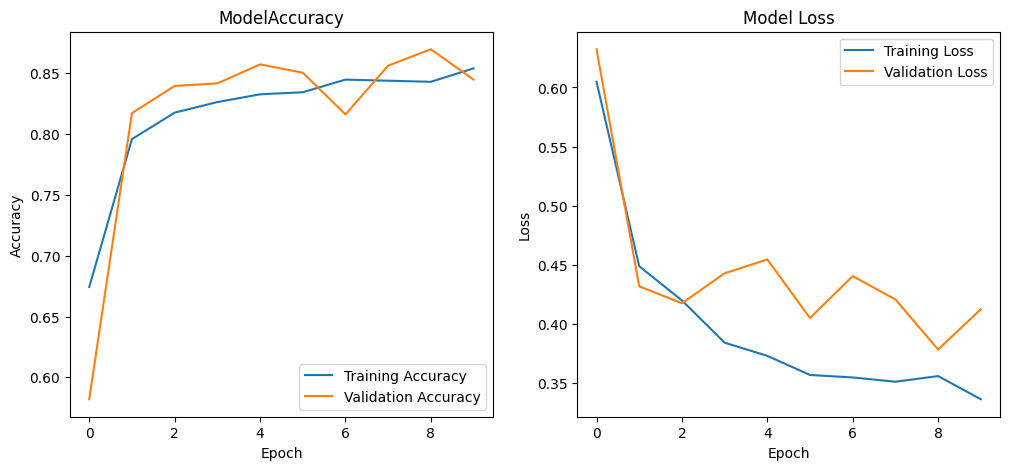

In [39]:
plt.figure(figsize=(12, 5))

# Plotting training and validation accuracy
plt.subplot(1, 2, 1)
plt.plot(cnn1.history['accuracy'], label='Training Accuracy')
plt.plot(cnn1.history['val_accuracy'], label='Validation Accuracy')
plt.title('ModelAccuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(cnn1.history['loss'], label='Training Loss')
plt.plot(cnn1.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

In [40]:
save('cancer.keras')

The following commands were written to file `('cancer.keras').py`:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# image size and batch size
image_size = (512, 512,3)                   #height,width,color channels
batch_size = 32

# Directory for the training set
train_dir = "D:\ML\archive\melanoma_cancer_dataset\train"
                                                        #ADD PATH 
# Directory for the testing set
test_dir = "D:\ML\archive\melanoma_cancer_dataset\test"

# ImageDataGenerator for rescaling and image augmentation (helps reduce overfitting)
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2,                # 20% of the training data will be used for validation
                                    rotation_range=20,                                  # Randomly rotate images
                   